# Step 1 - Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
from sklearn import linear_model

print("Imports OK")

Imports OK


# Step 2 - Configuration

In [3]:
split_dir  = Path("../data/split")
output_dir = Path("../data/results")

nintervals = 96

features = [
    "price_lag1d",
    "price_lag7d",
    "price_hourly_lag1d",
    "price_hourly_lag7d",
    "wind_mwh",
    "solar_mwh",
    "load_mwh",
]
target  = "price_eur_mwh"

# Rolling windows adapted from Lebedev et al. (1461, 1092, 84, 56)
windows = [100, 84, 56, 28]

# LEAR regularisation parameter from Lebedev et al. (2025)
lasso_alpha    = 0.0034079864342526534
lasso_max_iter = 10000

print(f"Windows      : {windows} days")
print(f"Lasso alpha  : {lasso_alpha}")

Windows      : [100, 84, 56, 28] days
Lasso alpha  : 0.0034079864342526534


# Step 3 - Laod Data

In [4]:
df = pd.read_csv(split_dir / "feature_matrix_clean.csv", parse_dates=["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

train_days = [pd.Timestamp(d).date() for d in pd.read_csv(split_dir / "train_days.csv")["date"]]
test_days  = [pd.Timestamp(d).date() for d in pd.read_csv(split_dir / "test_days.csv")["date"]]
all_days   = sorted(df["timestamp"].dt.date.unique())

n_train = len(train_days)   # 100
n_test  = len(test_days)    # 44
n_total = len(all_days)     # 144

X_all = df[features].values   # (13824, 7)
y_all = df[target].values     # (13824,)

print(f"X_all : {X_all.shape}")
print(f"y_all : {y_all.shape}")
print(f"Train : {n_train} days")
print(f"Test  : {n_test} days")

X_all : (13824, 7)
y_all : (13824,)
Train : 100 days
Test  : 44 days


# Step 4 - Normalization 
Mean-std standardization using training data statistics only (Lebedev et al.)

In [5]:
train_end   = n_train * nintervals
X_train_raw = X_all[:train_end, :]
y_train_raw = y_all[:train_end]

offset_X = X_train_raw.mean(axis=0)
scale_X  = X_train_raw.std(axis=0)
scale_X[scale_X == 0] = 1.0

offset_y = float(y_train_raw.mean())
scale_y  = float(y_train_raw.std())

X_norm = (X_all - offset_X) / scale_X
y_norm = (y_all - offset_y) / scale_y

print(f"offset_y (mean price) : {offset_y:.4f} EUR/MWh")
print(f"scale_y  (std price)  : {scale_y:.4f} EUR/MWh")

offset_y (mean price) : 95.2633 EUR/MWh
scale_y  (std price)  : 43.5266 EUR/MWh


# Step 5 - Rolling-Window Evaluation

In [6]:
lear_pred_windows = {w: np.zeros((n_test, nintervals)) for w in windows}

for w in windows:
    print(f"Window {w:>3d} days ...", end=" ", flush=True)
    for i in range(n_test):
        forecast_day_idx  = n_train + i
        window_start_idx  = max(forecast_day_idx - w, 0)

        row_start = window_start_idx * nintervals
        row_end   = forecast_day_idx * nintervals
        row_pred  = forecast_day_idx * nintervals

        reg = linear_model.Lasso(alpha=lasso_alpha, max_iter=lasso_max_iter)
        reg.fit(
            X=X_norm[row_start:row_end, :],
            y=y_norm[row_start:row_end],
        )
        lear_pred_windows[w][i, :] = reg.predict(
            X=X_norm[row_pred:row_pred + nintervals, :]
        )

    y_test_norm = y_norm[train_end:].reshape(n_test, nintervals)
    errors = (y_test_norm - lear_pred_windows[w]) * scale_y
    mae_w  = float(np.mean(np.abs(errors)))
    print(f"MAE = {mae_w:.4f} EUR/MWh")

print("\nAll windows done")

Window 100 days ... MAE = 11.9429 EUR/MWh
Window  84 days ... MAE = 12.3252 EUR/MWh
Window  56 days ... MAE = 12.9953 EUR/MWh
Window  28 days ... MAE = 12.4108 EUR/MWh

All windows done


# Step 6 - Average and Evaluate

In [7]:
lear_pred_mean = np.mean([lear_pred_windows[w] for w in windows], axis=0)

y_test_norm = y_norm[train_end:].reshape(n_test, nintervals)
y_test_orig = y_test_norm * scale_y + offset_y
y_pred_orig = lear_pred_mean * scale_y + offset_y

errors = y_test_orig - y_pred_orig
mae    = float(np.mean(np.abs(errors)))

print("  LEAR — Test Set Results")
print(f"  MAE : {mae:.4f} EUR/MWh")

print("\nPer-window MAE:")
for w in windows:
    e = (y_test_norm - lear_pred_windows[w]) * scale_y
    print(f"  Window {w:>3d} days: {np.mean(np.abs(e)):.4f} EUR/MWh")

  LEAR — Test Set Results
  MAE : 12.1267 EUR/MWh

Per-window MAE:
  Window 100 days: 11.9429 EUR/MWh
  Window  84 days: 12.3252 EUR/MWh
  Window  56 days: 12.9953 EUR/MWh
  Window  28 days: 12.4108 EUR/MWh


# Step 7 - Forecast Plot

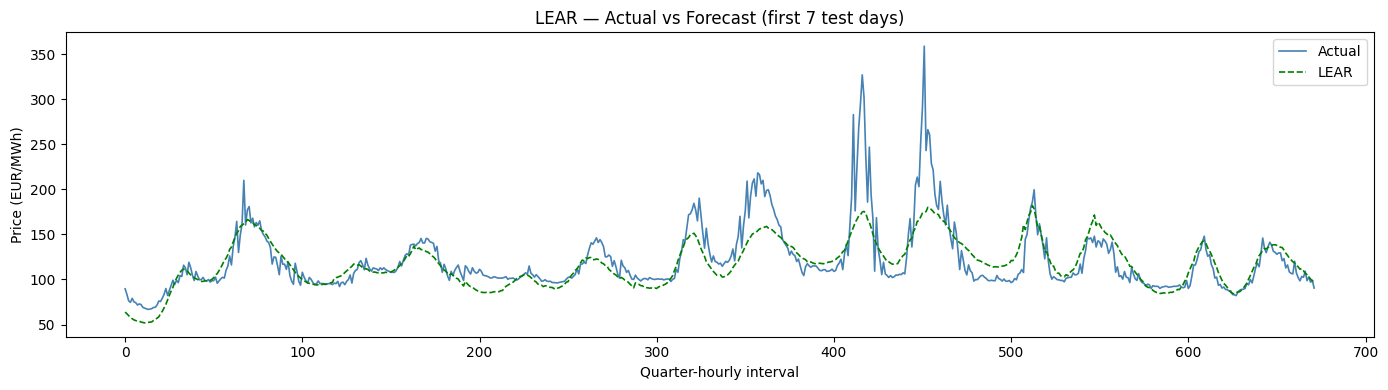

Plot saved


In [8]:
n_days = 7
n_plot = n_days * nintervals

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(y_test_orig.flatten()[:n_plot], label="Actual", linewidth=1.2, color="steelblue")
ax.plot(y_pred_orig.flatten()[:n_plot], label="LEAR",   linewidth=1.2, color="green", linestyle="--")
ax.set_title("LEAR — Actual vs Forecast (first 7 test days)")
ax.set_xlabel("Quarter-hourly interval")
ax.set_ylabel("Price (EUR/MWh)")
ax.legend()
plt.tight_layout()
plt.savefig(output_dir / "LEAR_forecast_plot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved")

# Step 8 - Save Results

In [9]:
lear_dict = {
    "model_name"   : "LEAR",
    "prediction"   : y_pred_orig,
    "y_test"       : y_test_orig,
    "offset"       : offset_y,
    "scale"        : scale_y,
    "mae"          : mae,
    "test_days"    : [str(d) for d in test_days],
    "pred_windows" : {w: lear_pred_windows[w] * scale_y + offset_y for w in windows},
}

with open(output_dir / "LEAR.pkl", "wb") as f:
    pickle.dump([lear_dict], f)

print(f"Saved: {output_dir / 'LEAR.pkl'}")
print("LEAR.ipynb complete")

Saved: ..\data\results\LEAR.pkl
LEAR.ipynb complete
